In [3]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'


In [4]:
import os
import numpy as np
import os, glob, json
import nibabel as nib
from scipy import ndimage
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.transform import resize
from nilearn.image import resample_img
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation

In [5]:

# Prevent memory issues - add this after importing tensorflow
import tensorflow as tf

# Enable memory growth for both GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for all GPUs")
    except RuntimeError as e:
        print(e)

Memory growth enabled for all GPUs


In [6]:
# Enable mixed precision (faster, less memory)
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled")

Mixed precision enabled


In [7]:
# --- SETTINGS from second code ---
TARGET_SHAPE = (128, 128, 128)
N_CLASSES = 4
BATCH_SIZE = 1

def reorient_to_ras(data, affine):
    """
    Reorient NIfTI data array to RAS orientation.
    """
    current_ornt = io_orientation(affine)
    ras_ornt = axcodes2ornt(('R','A','S'))
    transform = ornt_transform(current_ornt, ras_ornt)
    return apply_orientation(data, transform)

# --- Paths from second code ---
train_image_dir = "MRIs_SPLIT/train/images"
train_mask_dir = "MRIs_SPLIT/train/masks"
val_image_dir = "MRIs_SPLIT/val/images"
val_mask_dir = "MRIs_SPLIT/val/masks"
test_image_dir = "MRIs_SPLIT/test/images"
test_mask_dir = "MRIs_SPLIT/test/masks"

# --- Utility to load and preprocess one sample ---
def preprocess_sample(image_path, mask_path, target_shape=TARGET_SHAPE, n_classes=N_CLASSES, visualize=False):
    # Decode if paths come from tf.data pipeline
    if hasattr(image_path, "numpy"):
        image_path = image_path.numpy().decode()
    if hasattr(mask_path, "numpy"):
        mask_path = mask_path.numpy().decode()
    
    # Load NIfTI
    img_nii = nib.load(image_path)
    mask_nii = nib.load(mask_path)
    
    # Resample mask to image affine (nearest for labels)
    mask_resampled_nii = resample_img(
        mask_nii, 
        target_affine=img_nii.affine, 
        target_shape=img_nii.shape,
        interpolation='nearest'
    )
    
    # 🔹 Reorient to RAS
    img_ras = reorient_to_ras(img_nii.get_fdata(), img_nii.affine)
    mask_ras = reorient_to_ras(mask_resampled_nii.get_fdata(), mask_resampled_nii.affine)
    
    # Resize to target shape
    if img_ras.shape != target_shape:
        img_ras = resize(img_ras, target_shape, preserve_range=True)
    if mask_ras.shape != target_shape:
        mask_ras = resize(mask_ras, target_shape, order=0, preserve_range=True)
    
    # Normalize image
    img_ras = (img_ras - img_ras.min()) / (img_ras.max() - img_ras.min())
    img_ras = np.expand_dims(img_ras, axis=-1)
    
    # Round mask and one-hot encode
    mask_ras = np.rint(mask_ras).astype(np.int32)
    mask_ras = tf.keras.utils.to_categorical(mask_ras, num_classes=n_classes)
    
    return img_ras.astype(np.float32), mask_ras.astype(np.float32)

# --- TensorFlow wrapper for generator ---
def tf_preprocess(image_path, mask_path):
    img, mask = tf.py_function(func=preprocess_sample,
                               inp=[image_path, mask_path],
                               Tout=[tf.float32, tf.float32])
    img.set_shape(TARGET_SHAPE + (1,))
    mask.set_shape(TARGET_SHAPE + (N_CLASSES,))
    return img, mask

# --- Create tf.data dataset ---
def create_dataset(image_dir, mask_dir, batch_size=BATCH_SIZE, shuffle=True):
    image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.nii', '.nii.gz'))])
    mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(('.nii', '.nii.gz'))])
    
    # Verify we have matching pairs
    if len(image_paths) != len(mask_paths):
        print(f"Warning: Mismatch between images ({len(image_paths)}) and masks ({len(mask_paths)}) in {image_dir}")
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# --- Create datasets ---
print("Creating datasets...")
train_dataset = create_dataset(train_image_dir, train_mask_dir)
val_dataset = create_dataset(val_image_dir, val_mask_dir, shuffle=False)
test_dataset = create_dataset(test_image_dir, test_mask_dir, shuffle=False)

# Print dataset info
print(f"Train dataset: {len(os.listdir(train_image_dir))} images")
print(f"Val dataset: {len(os.listdir(val_image_dir))} images")
print(f"Test dataset: {len(os.listdir(test_image_dir))} images")
print("Datasets created successfully!")

Creating datasets...
Train dataset: 529 images
Val dataset: 151 images
Test dataset: 76 images
Datasets created successfully!


I0000 00:00:1758612324.111618   15691 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:17:00.0, compute capability: 7.5
I0000 00:00:1758612324.112071   15691 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9516 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:65:00.0, compute capability: 7.5


In [8]:
import random

class ADNISequence(tf.keras.utils.Sequence):
    def __init__(self, image_dir, mask_dir, batch_size=BATCH_SIZE, target_shape=TARGET_SHAPE,
                 patch_training=False, patches_per_volume=8, shuffle=True):
        # Use the same path gathering logic from your working create_dataset
        self.image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.nii', '.nii.gz'))])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(('.nii', '.nii.gz'))])
        
        self.batch_size = batch_size
        self.target_shape = target_shape
        self.patch_training = patch_training
        self.patches_per_volume = patches_per_volume
        self.shuffle = shuffle
        self.indices = list(range(len(self.image_paths)))
        self.on_epoch_end()

    def __len__(self):
        if self.patch_training:
            return int(np.ceil(len(self.image_paths) * self.patches_per_volume / self.batch_size))
        else:
            return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.indices)

    def __getitem__(self, idx):
        X_batch = []
        Y_batch = []
        
        if self.patch_training:
            for _ in range(self.batch_size):
                subj_idx = random.choice(self.indices)
                img, mask = self._load_and_preprocess(subj_idx)
                patch_x, patch_y = self._random_patch(img, mask)
                X_batch.append(patch_x)
                Y_batch.append(patch_y)
        else:
            batch_indices = self.indices[idx * self.batch_size: (idx + 1) * self.batch_size]
            for subj_idx in batch_indices:
                img, mask = self._load_and_preprocess(subj_idx)
                X_batch.append(img)
                Y_batch.append(mask)
        
        return np.array(X_batch, dtype=np.float32), np.array(Y_batch, dtype=np.float32)

    def _load_and_preprocess(self, subj_idx):
        # Use your existing preprocess_sample function logic
        image_path = self.image_paths[subj_idx]
        mask_path = self.mask_paths[subj_idx]
        
        img = nib.load(image_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        img = resize(img, self.target_shape, preserve_range=True)
        mask = resize(mask, self.target_shape, order=0, preserve_range=True)

        img = (img - img.min()) / (img.max() - img.min())
        img = np.expand_dims(img, axis=-1)

        mask = np.rint(mask).astype(np.int32)
        mask = tf.keras.utils.to_categorical(mask, num_classes=N_CLASSES)

        return img, mask

    def _random_patch(self, img, mask):
        ts = np.array(self.target_shape)
        shape = np.array(img.shape[:3])
        
        if np.any(shape < ts):
            pad_width = np.maximum(ts - shape, 0)
            pad_before = pad_width // 2
            pad_after = pad_width - pad_before
            
            img_padded = np.pad(img, [(pad_before[i], pad_after[i]) for i in range(3)] + [(0, 0)], mode='constant')
            mask_padded = np.pad(mask, [(pad_before[i], pad_after[i]) for i in range(3)] + [(0, 0)], mode='constant')
            shape = np.array(img_padded.shape[:3])
        else:
            img_padded = img
            mask_padded = mask

        max_start = shape - ts
        starts = [np.random.randint(0, max_start[i] + 1) if max_start[i] > 0 else 0 for i in range(3)]
        z0, y0, x0 = starts
        z1, y1, x1 = z0 + ts[0], y0 + ts[1], x0 + ts[2]
        
        patch_x = img_padded[z0:z1, y0:y1, x0:x1]
        patch_y = mask_padded[z0:z1, y0:y1, x0:x1]
        
        return patch_x, patch_y

# Replace the dataset creation with ADNISequence
train_dataset = ADNISequence(train_image_dir, train_mask_dir, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = ADNISequence(val_image_dir, val_mask_dir, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = ADNISequence(test_image_dir, test_mask_dir, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_dataset)} batches")
print(f"Val sequences: {len(val_dataset)} batches")
print(f"Test sequences: {len(test_dataset)} batches")
print("ADNISequence datasets created successfully!")

Train sequences: 529 batches
Val sequences: 151 batches
Test sequences: 76 batches
ADNISequence datasets created successfully!


In [9]:
def conv2p1d_block(x, filters, dropout=0.2):
    x = layers.Conv3D(filters, (1,3,3), padding='same', activation='elu')(x)
    x = layers.Conv3D(filters, (3,1,1), padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)
    if dropout>0:
        x = layers.Dropout(dropout)(x)
    return x

def build_2p1d_unet(input_shape=TARGET_SHAPE + (1,), num_classes=N_CLASSES, base_filters=64):
    inputs = layers.Input(shape=input_shape)
    # Encoder
    x1 = conv2p1d_block(inputs, base_filters)
    p1 = layers.MaxPool3D((2,2,2))(x1)
    x2 = conv2p1d_block(p1, base_filters//2)
    p2 = layers.MaxPool3D((2,2,2))(x2)
    x3 = conv2p1d_block(p2, base_filters//4)
    p3 = layers.MaxPool3D((2,2,2))(x3)
    x4 = conv2p1d_block(p3, base_filters//8)
    p4 = layers.MaxPool3D((2,2,2))(x4)
    # Bridge
    b = conv2p1d_block(p4, base_filters//8)
    # Decoder
    u4 = layers.Conv3DTranspose(base_filters//8, (2,2,2), strides=(2,2,2), padding='same')(b)
    u4 = layers.Concatenate()([u4, x4])
    d4 = conv2p1d_block(u4, base_filters//8)
    u3 = layers.Conv3DTranspose(base_filters//4, (2,2,2), strides=(2,2,2), padding='same')(d4)
    u3 = layers.Concatenate()([u3, x3])
    d3 = conv2p1d_block(u3, base_filters//4)
    u2 = layers.Conv3DTranspose(base_filters//2, (2,2,2), strides=(2,2,2), padding='same')(d3)
    u2 = layers.Concatenate()([u2, x2])
    d2 = conv2p1d_block(u2, base_filters//2)
    u1 = layers.Conv3DTranspose(base_filters, (2,2,2), strides=(2,2,2), padding='same')(d2)
    u1 = layers.Concatenate()([u1, x1])
    d1 = conv2p1d_block(u1, base_filters)
    outputs = layers.Conv3D(num_classes, (1,1,1), activation='softmax')(d1)
    model = models.Model(inputs, outputs)
    return model

print('Model builder ready.')

# Build the model
model = build_2p1d_unet()
model.summary()

Model builder ready.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 128, 128,  │     12,352 │ conv3d[0][0]      │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ dropout[0][0]     │
│ (MaxPooling3D)      │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │     18,464 │ max_pooling3d[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 64, 64,    │      3,104 │ conv3d_2[0][0]    │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling3D)      │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │      4,624 │ max_pooling3d_1[… │
│                     │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 32, 32,    │        784 │ conv3d_4[0][0]    │
│                     │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv3d_5[0][0]    │
│ (BatchNormalizatio… │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 16, 16,    │          0 │ dropout_2[0][0]   │
│ (MaxPooling3D)      │ 16, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 16,    │      1,160 │ max_pooling3d_2[

 Total params: 179,980 (703.05 KB)

 Trainable params: 179,484 (701.11 KB)

 Non-trainable params: 496 (1.94 KB)

In [10]:
def dice_coeff(y_true, y_pred, smooth=1e-6, class_index=None):
    # y_true is already one-hot encoded, no need for tf.one_hot
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)
    if class_index is not None:
        y_true_f = y_true_f[..., class_index]
        y_pred_f = y_pred_f[..., class_index]
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denom = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2. * intersection + smooth) / (denom + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - tf.reduce_mean([dice_coeff(y_true, y_pred, class_index=i) for i in range(N_CLASSES)])

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)  # Changed to categorical_crossentropy
    dl = dice_loss(y_true, y_pred)
    return tf.reduce_mean(ce) + dl

print('Loss & metrics defined.')


Loss & metrics defined.


In [11]:
LEARNING_RATE = 1e-4
input_shape = TARGET_SHAPE + (1,)
model = build_2p1d_unet(input_shape=input_shape, num_classes=N_CLASSES, base_filters=64)
opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss=combined_loss, metrics=['accuracy'])
model.summary()
print('\nModel compiled. Do a quick parameter check to estimate memory. If it is too big, reduce base_filters or TARGET_SHAPE.')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_19 (Conv3D)  │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_20 (Conv3D)  │ (None, 128, 128,  │     12,352 │ conv3d_19[0][0]   │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv3d_20[0][0]   │
│ (BatchNormalizatio… │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 64, 64,    │          0 │ dropout_9[0][0]   │
│ (MaxPooling3D)      │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_21 (Conv3D)  │ (None, 64, 64,    │     18,464 │ max_pooling3d_4[… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_22 (Conv3D)  │ (None, 64, 64,    │      3,104 │ conv3d_21[0][0]   │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv3d_22[0][0]   │
│ (BatchNormalizatio… │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_5     │ (None, 32, 32,    │          0 │ dropout_10[0][0]  │
│ (MaxPooling3D)      │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_23 (Conv3D)  │ (None, 32, 32,    │      4,624 │ max_pooling3d_5[… │
│                     │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_24 (Conv3D)  │ (None, 32, 32,    │        784 │ conv3d_23[0][0]   │
│                     │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv3d_24[0][0]   │
│ (BatchNormalizatio… │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_6     │ (None, 16, 16,    │          0 │ dropout_11[0][0]  │
│ (MaxPooling3D)      │ 16, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_25 (Conv3D)  │ (None, 16, 16,    │      1,160 │ max_pooling3d_6[

 Total params: 179,980 (703.05 KB)

 Trainable params: 179,484 (701.11 KB)

 Non-trainable params: 496 (1.94 KB)


Model compiled. Do a quick parameter check to estimate memory. If it is too big, reduce base_filters or TARGET_SHAPE.


In [12]:
print('Train subjects:', len(train_dataset.image_paths), 'Val subjects:', len(val_dataset.image_paths))
print('Test subjects:', len(test_dataset.image_paths))

Train subjects: 529 Val subjects: 151
Test subjects: 76


In [ ]:
OUT_DIR = "2p1d_unet_outputs"
ckpt_path = os.path.join(OUT_DIR, 'checkpoints', 'best_model.keras')
tb_logdir = os.path.join(OUT_DIR, 'tb')  # <-- ADD THIS LINE

class EpochLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(f"Epoch {epoch+1}: " + ", ".join([f"{k}={v:.4f}" for k, v in logs.items()]))


# Create directories
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
os.makedirs(tb_logdir, exist_ok=True)  # <-- CREATE TB DIRECTORY

# NOW create callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path, 
        monitor='val_loss', 
        save_best_only=True, 
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(tb_logdir),  # Now tb_logdir is defined
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, verbose=1, restore_best_weights=True),
    EpochLogger()
]
# 4. Compile and train
model.compile(optimizer=opt, loss=combined_loss, metrics=['accuracy'])
history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=50,
                    callbacks=callbacks)

/home/e.yavarova/miniconda/envs/alzheimers_venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


2025-09-23 11:26:20.676202: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ff5e4120a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-23 11:26:20.676238: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-09-23 11:26:20.676246: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-09-23 11:26:20.861268: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-23 11:26:22.209762: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-09-23 11:26:40.361572: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f16[64,128,1,3,3]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[1,128,128,12

529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.4838 - loss: 2.2136
Epoch 1: val_loss improved from None to 1.03378, saving model to 2p1d_unet_outputs/checkpoints/best_model.keras
Epoch 1: accuracy=0.6987, loss=1.8546, val_accuracy=0.9460, val_loss=1.0338, learning_rate=0.0001
529/529 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.6987 - loss: 1.8546 - val_accuracy: 0.9460 - val_loss: 1.0338 - learning_rate: 1.0000e-04
Epoch 2/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.9410 - loss: 1.1934

In [2]:
# Load model without compiling (since we don't need to train)
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

NameError: name 'tf' is not defined

2025-09-24 14:41:04.534465: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 14:41:04.700273: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 14:41:05.903074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1758710468.313491   51244 gpu_device.cc:2020] Created device /job:lo

Loading model from 2p1d_unet_outputs/checkpoints/best_model.keras...
Model loaded successfully!
Loading validation dataset...
Evaluating model...


2025-09-24 14:41:17.930639: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2025-09-24 14:41:17.974575: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fc4cc0041f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-24 14:41:17.974707: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-09-24 14:41:17.974722: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2025-09-24 14:41:18.139323: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2025-09-24 14:41:19.066154: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


I0000 00:00:1758710491.327313   51346 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


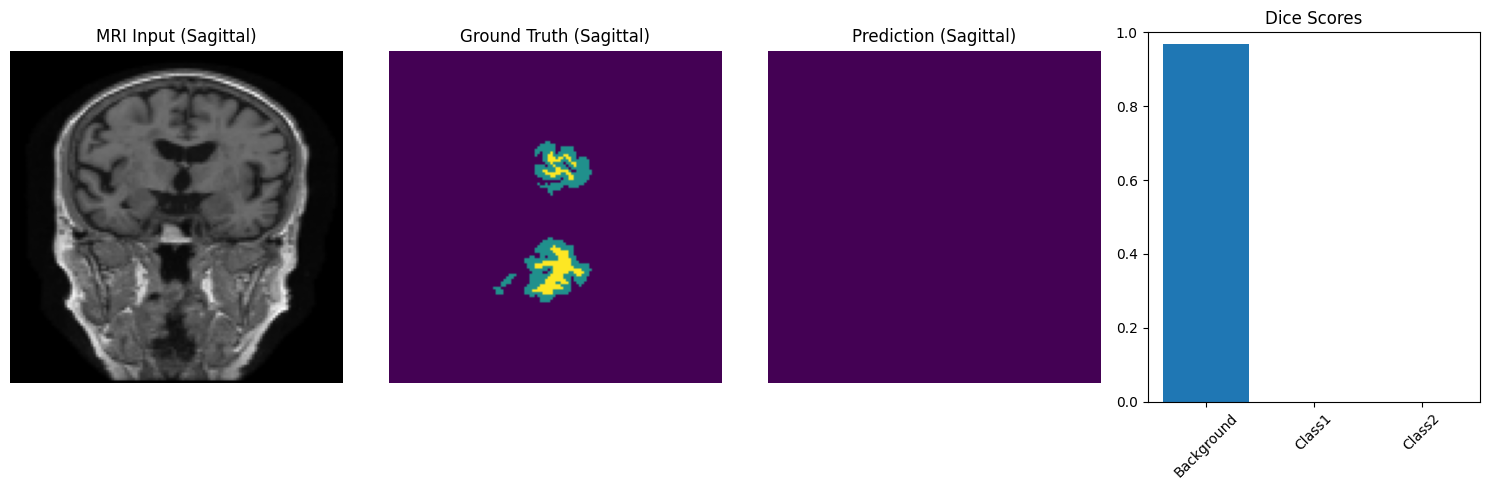

Case 1 Dice scores: ['0.969', '0.000', '0.000']


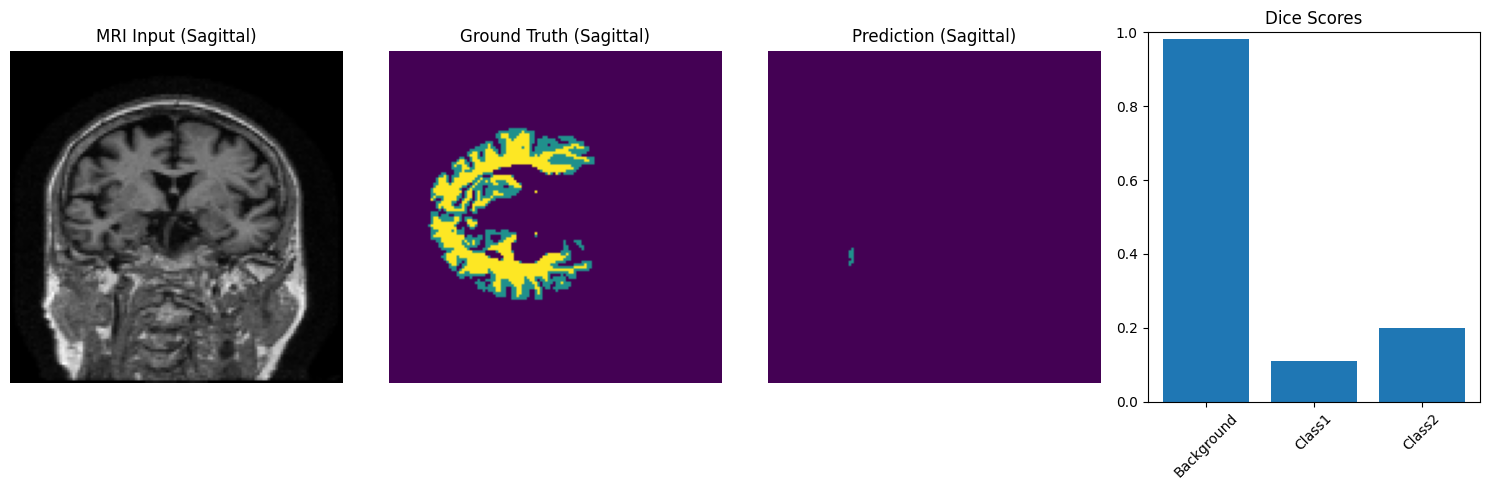

Case 2 Dice scores: ['0.982', '0.111', '0.200']


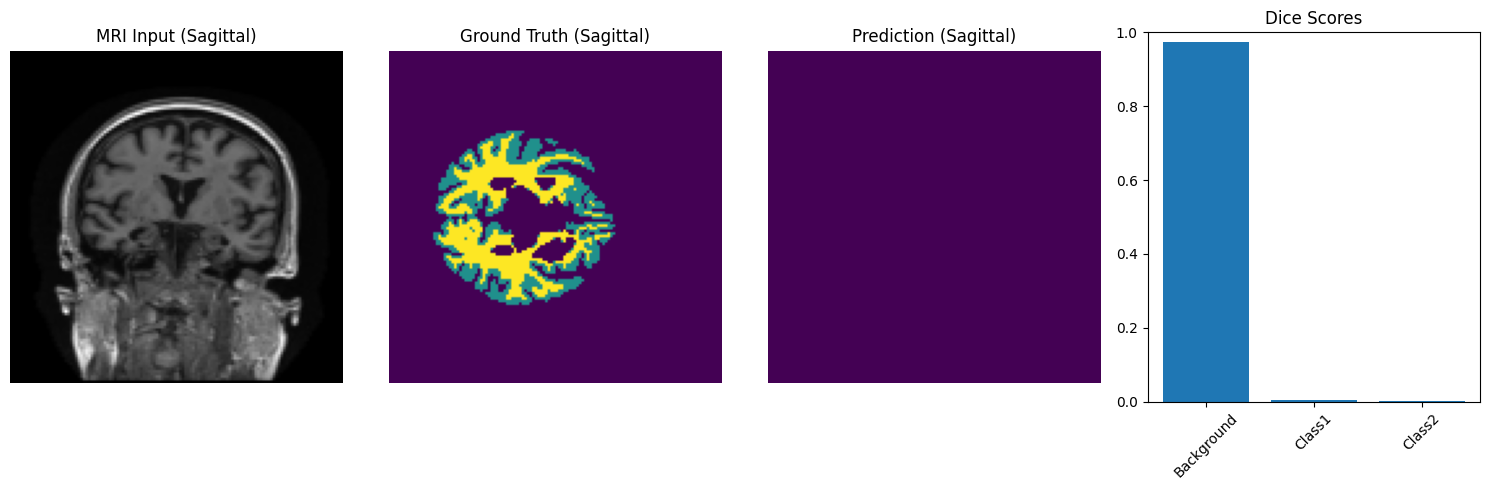

Case 3 Dice scores: ['0.973', '0.005', '0.000']

=== FINAL RESULTS ===
Dice scores shape: (3, 3)
Mean Dice per class: [0.97478239 0.03859678 0.06673874]
Overall mean Dice: 0.3600 ± 0.4392


2025-09-24 14:41:33.053666: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


: 

In [ ]:
import os
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# --- Configuration ---
MODEL_PATH = "2p1d_unet_outputs/checkpoints/best_model.keras"
N_CLASSES = 3
TARGET_SHAPE = (128, 128, 128)
BATCH_SIZE = 2

import tensorflow as tf
from keras.src.saving import register_keras_serializable

@register_keras_serializable()
def combined_loss(y_true, y_pred):
    # Your loss function implementation
    alpha = 0.5
    beta = 0.5
    
    # Example: combination of categorical crossentropy and focal loss
    cce = tf.keras.losses.CategoricalCrossentropy()(y_true, y_pred)
    
    # Focal loss component (example)
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)
    focal_loss = tf.reduce_mean(tf.reduce_sum(cross_entropy, axis=-1))
    
    return alpha * cce + beta * focal_loss

# Then load your model
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'combined_loss': combined_loss})

# --- Load the trained model ---
print(f"Loading model from {MODEL_PATH}...")
print("Model loaded successfully!")

# --- Create evaluation function ---
def eval_on_dataset(dataset, n_cases=5):
    dices = []
    for i, (X, Y) in enumerate(dataset.take(n_cases)):
        # Predict
        pred = model.predict(X, verbose=0)
        
        # Convert to class labels
        true = np.argmax(Y[0], axis=-1) if len(Y.shape) == 5 else Y[0]
        pr = np.argmax(pred[0], axis=-1)
        
        # Calculate Dice for each class
        case_dices = []
        for c in range(N_CLASSES):
            y_true_c = (true == c).astype(np.int32)
            y_pred_c = (pr == c).astype(np.int32)
            inter = np.sum(y_true_c * y_pred_c)
            denom = np.sum(y_true_c) + np.sum(y_pred_c)
            dice = (2 * inter + 1e-6) / (denom + 1e-6) if denom > 0 else 0
            case_dices.append(dice)
        
        dices.append(case_dices)
        
        # Visualize middle slice - NOW IN SAGITTAL VIEW
        mid_sagittal = TARGET_SHAPE[1] // 2  # Middle sagittal slice (y-axis)
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 4, 1)
        plt.title('MRI Input (Sagittal)')
        plt.imshow(X[0, :, mid_sagittal, :, 0], cmap='gray')  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.title('Ground Truth (Sagittal)')
        plt.imshow(true[:, mid_sagittal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.title('Prediction (Sagittal)')
        plt.imshow(pr[:, mid_sagittal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.title('Dice Scores')
        classes = ['Background', 'Class1', 'Class2', 'Class3'][:N_CLASSES]
        plt.bar(classes, case_dices)
        plt.ylim(0, 1)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Case {i+1} Dice scores: {[f'{d:.3f}' for d in case_dices]}")
    
    return np.array(dices)

# --- Load your datasets ---
def load_datasets():
    # Update these paths to your actual data directories
    train_image_dir = "MRIs_SPLIT/train/images"
    train_mask_dir = "MRIs_SPLIT/train/masks"
    val_image_dir = "MRIs_SPLIT/val/images"
    val_mask_dir = "MRIs_SPLIT/val/masks"
    
    # Use your existing create_dataset function
    val_dataset = create_dataset(val_image_dir, val_mask_dir, batch_size=BATCH_SIZE, shuffle=False)
    return val_dataset

def create_dataset(image_dir, mask_dir, batch_size=BATCH_SIZE, shuffle=True):
    # Your existing dataset creation function here
    image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(('.nii', '.nii.gz'))])
    mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(('.nii', '.nii.gz'))])
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def tf_preprocess(image_path, mask_path):
    # Your existing preprocessing function
    img, mask = tf.py_function(func=preprocess_sample, inp=[image_path, mask_path], Tout=[tf.float32, tf.float32])
    img.set_shape(TARGET_SHAPE + (1,))
    mask.set_shape(TARGET_SHAPE + (N_CLASSES,))
    return img, mask

def preprocess_sample(image_path, mask_path):
    # Your existing preprocessing
    import nibabel as nib
    from skimage.transform import resize
    
    img = nib.load(image_path.numpy().decode()).get_fdata()
    mask = nib.load(mask_path.numpy().decode()).get_fdata()
    
    # REORIENT MASK TO SAGITTAL IF NEEDED
    # Check if mask needs reorientation (assuming your ground truth is in sagittal orientation)
    # If mask has different orientation than image, you may need to transpose it
    if img.shape != mask.shape:
        print(f"Warning: Image shape {img.shape} != Mask shape {mask.shape}")
        # You might need to transpose the mask to match image orientation
        # Common reorientation: if mask is sagittal-first, you might need to permute axes
        # mask = np.transpose(mask, (1, 0, 2))  # Example: swap first two axes
    
    img = resize(img, TARGET_SHAPE, preserve_range=True)
    mask = resize(mask, TARGET_SHAPE, order=0, preserve_range=True)  # order=0 for nearest neighbor
    
    img = (img - img.min()) / (img.max() - img.min())
    img = np.expand_dims(img, axis=-1)
    
    mask = np.rint(mask).astype(np.int32)
    mask = tf.keras.utils.to_categorical(mask, num_classes=N_CLASSES)
    
    return img.astype(np.float32), mask.astype(np.float32)

# --- Alternative: If your ground truth is already in sagittal orientation ---
def preprocess_sample_sagittal_gt(image_path, mask_path):
    """Alternative preprocessing assuming ground truth is in sagittal orientation"""
    import nibabel as nib
    from skimage.transform import resize
    
    # Load image and mask
    img = nib.load(image_path.numpy().decode()).get_fdata()
    mask = nib.load(mask_path.numpy().decode()).get_fdata()
    
    # If ground truth is sagittal, we might need to reorient it to match image
    # This depends on how your data is stored
    
    # Resize both to target shape
    img = resize(img, TARGET_SHAPE, preserve_range=True)
    mask = resize(mask, TARGET_SHAPE, order=0, preserve_range=True)  # order=0 for nearest neighbor
    
    # Normalize image
    img = (img - img.min()) / (img.max() - img.min())
    img = np.expand_dims(img, axis=-1)
    
    # Process mask
    mask = np.rint(mask).astype(np.int32)
    mask = tf.keras.utils.to_categorical(mask, num_classes=N_CLASSES)
    
    return img.astype(np.float32), mask.astype(np.float32)

# --- For visualization in different planes ---
def visualize_all_planes(X, true, pr, case_num):
    """Visualize all three planes: axial, coronal, and sagittal"""
    mid_axial = TARGET_SHAPE[0] // 2
    mid_coronal = TARGET_SHAPE[1] // 2  
    mid_sagittal = TARGET_SHAPE[2] // 2
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    # Axial view
    axes[0, 0].imshow(X[0, mid_axial, :, :, 0], cmap='gray')
    axes[0, 0].set_title('MRI Input (Axial)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(true[mid_axial, :, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[0, 1].set_title('Ground Truth (Axial)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(pr[mid_axial, :, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[0, 2].set_title('Prediction (Axial)')
    axes[0, 2].axis('off')
    
    # Coronal view
    axes[1, 0].imshow(X[0, :, mid_coronal, :, 0], cmap='gray')
    axes[1, 0].set_title('MRI Input (Coronal)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(true[:, mid_coronal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[1, 1].set_title('Ground Truth (Coronal)')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(pr[:, mid_coronal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[1, 2].set_title('Prediction (Coronal)')
    axes[1, 2].axis('off')
    
    # Sagittal view (your requested view)
    axes[2, 0].imshow(X[0, :, :, mid_sagittal, 0], cmap='gray')
    axes[2, 0].set_title('MRI Input (Sagittal)')
    axes[2, 0].axis('off')
    
    axes[2, 1].imshow(true[:, :, mid_sagittal], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[2, 1].set_title('Ground Truth (Sagittal)')
    axes[2, 1].axis('off')
    
    axes[2, 2].imshow(pr[:, :, mid_sagittal], cmap='viridis', vmin=0, vmax=N_CLASSES-1)
    axes[2, 2].set_title('Prediction (Sagittal)')
    axes[2, 2].axis('off')
    
    # Dice scores
    classes = ['Background', 'Class1', 'Class2'][:N_CLASSES]
    case_dices = []
    for c in range(N_CLASSES):
        y_true_c = (true == c).astype(np.int32)
        y_pred_c = (pr == c).astype(np.int32)
        inter = np.sum(y_true_c * y_pred_c)
        denom = np.sum(y_true_c) + np.sum(y_pred_c)
        dice = (2 * inter + 1e-6) / (denom + 1e-6) if denom > 0 else 0
        case_dices.append(dice)
    
    axes[2, 3].bar(classes, case_dices)
    axes[2, 3].set_title('Dice Scores')
    axes[2, 3].set_ylim(0, 1)
    axes[2, 3].tick_params(axis='x', rotation=45)
    
    # Hide unused subplots
    for i in range(2):
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Case {case_num} - All Planes', fontsize=16)
    plt.show()
    
    return case_dices

# --- Run evaluation ---
if __name__ == "__main__":
    print("Loading validation dataset...")
    val_dataset = load_datasets()
    
    print("Evaluating model...")
    dices = eval_on_dataset(val_dataset, n_cases=3)
    
    print("\n=== FINAL RESULTS ===")
    print(f"Dice scores shape: {dices.shape}")
    print(f"Mean Dice per class: {np.mean(dices, axis=0)}")
    print(f"Overall mean Dice: {np.mean(dices):.4f} ± {np.std(dices):.4f}")

In [ ]:
# See what mask files you actually have
mask_files = os.listdir(train_mask_dir)
print("First 10 mask files:", mask_files[:10])
print("First 10 image files:", os.listdir(train_image_dir)[:10])

# Check if there's a pattern
image_files = os.listdir(train_image_dir)
for img_file in image_files[:5]:
    print(f"Image: {img_file}")
    mask_file = find_matching_mask(img_file, train_mask_dir)
    print(f"Found mask: {mask_file}")

First 10 mask files: ['ADNI_016_S_1326_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20080421170033212_S47633_I103317_gm_wm_mask.nii.gz', 'ADNI_128_S_0205_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20080321161921516_S46888_I99301_gm_wm_mask.nii.gz', 'ADNI_136_S_0196_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20080516161530340_S49468_I105974_gm_wm_mask.nii.gz', 'ADNI_027_S_0835_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070810175009447_S28690_I66991_gm_wm_mask.nii.gz', 'ADNI_067_S_0607_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20071229185426117_S29073_I86415_gm_wm_mask.nii.gz', 'ADNI_128_S_0272_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070819161818170_S20038_I68938_gm_wm_mask.nii.gz', 'ADNI_014_S_0548_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20081022160912806_S52416_I122808_gm_wm_mask.nii.gz', 'ADNI_099_S_0551_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20080225181435042_S43126_I92572_gm_wm_mask.nii.gz', 'ADNI_005_S_1224_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080430162944735_S49188_I104

NameError: name 'find_matching_mask' is not defined